In [125]:
# Imports
import utils_plotting
import pickle
import jax.numpy as jnp
from utils_inverse import _tree_to_jnp
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Figure X: Optimization pipeline overview

In [124]:
path_inverse = f'checkpoints/co2/inverse_gaussian_tier1_co2_only.pkl'
with open(path_inverse, "rb") as f:
  raw = pickle.load(f)
res = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }

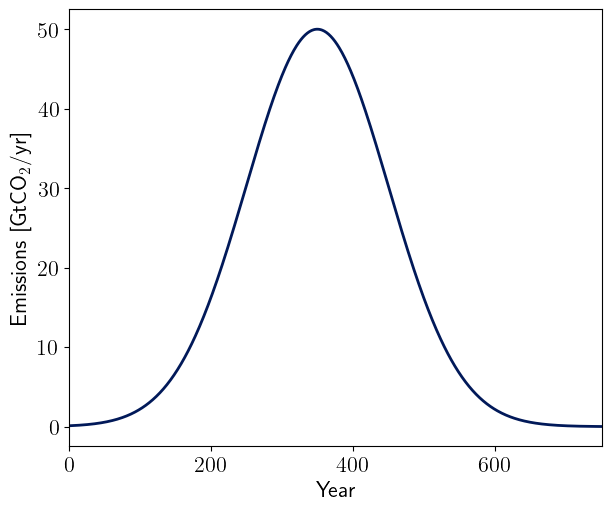

In [144]:
utils_plotting.plot_init(res, save=True)

In [149]:
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)
group = ['historical','H-ext','M','ML','L','VLHO','VLLO-ext']
years = [np.arange(1750, 2024), np.arange(2024, 2501), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2501)]

tier1 = []
for i, scen in enumerate(group):
  tier1.append(emis_dict_calib_JAX[scen][0])

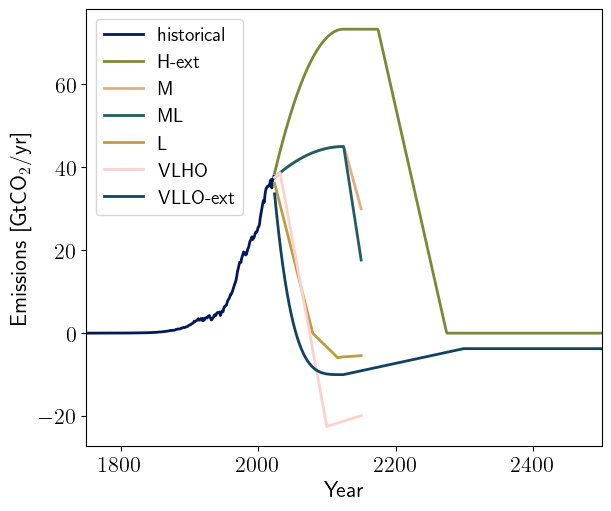

In [154]:
utils_plotting.plot_tier1(years, tier1, group, save=True)

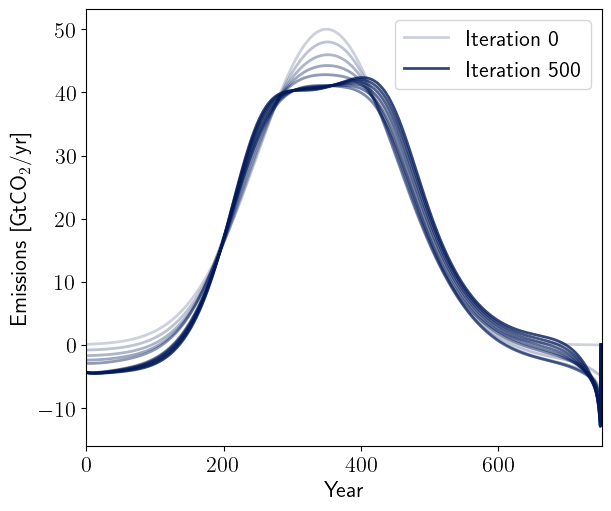

In [157]:
utils_plotting.plot_updates(res, save=True)

### Figure X: RMSE comparison across single-forcing experiments

In [20]:
agents = ['co2','ch4','n2o','Sulfur','BC']
results_inverse, results_baseline = [], []
for a in agents:
  path_inverse = f'checkpoints/{a}/inverse_constant_tier1_{a}_only.pkl'
  path_baseline = f'checkpoints/{a}/baseline_{a}_only.pkl'
  with open(path_inverse, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  with open(path_baseline, "rb") as f:
    res_base = pickle.load(f)
  results_inverse.append(out)
  results_baseline.append(res_base['Tier 1']['mean'])

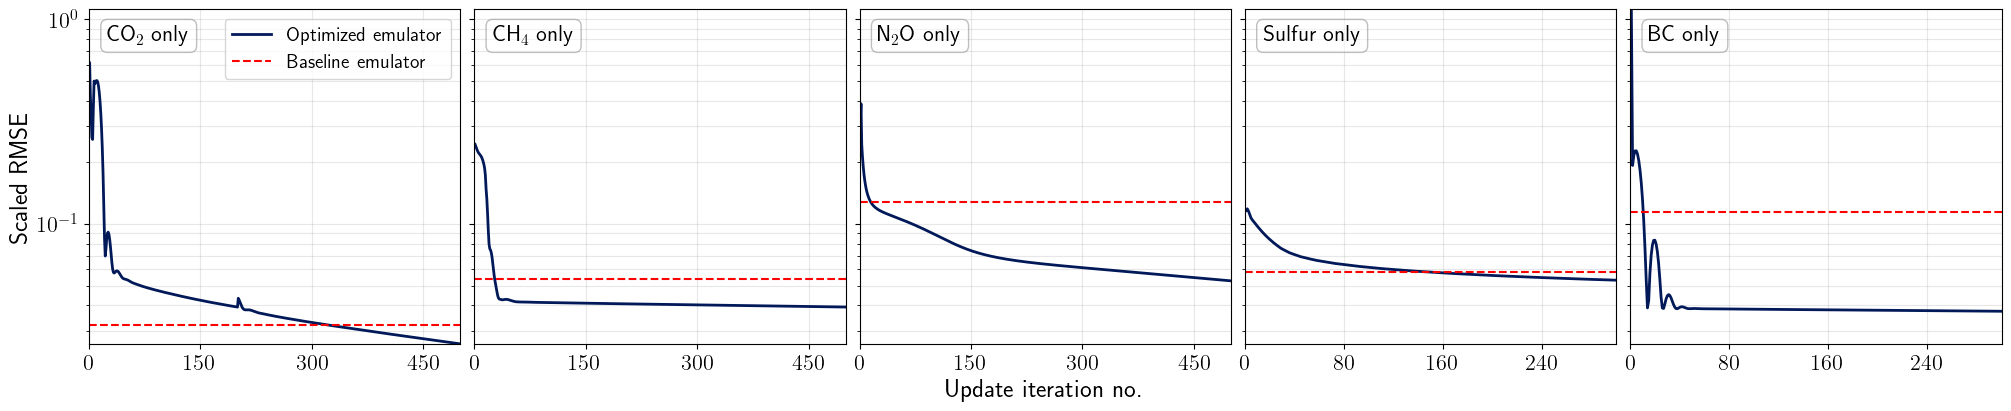

In [28]:
utils_plotting.plot_rmse_comparison(results_inverse, results_baseline, ['CO$_2$','CH$_4$','N$_2$O','Sulfur','BC'], save=True)

### Figure X: Optimal emissions profile across different optimization targets

In [215]:
from utils_FaIR_JAX import generate_calib_data

agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

plot_paths = ['checkpoints/co2/inverse_H-ext_constant_co2_only.pkl',
              #'checkpoints/co2/inverse_VLLO-ext_constant_co2_only.pkl',
              'checkpoints/co2/inverse_constant_DECK_co2_only.pkl',
              'checkpoints/co2/inverse_constant_tier1_co2_only.pkl']

opt_emissions = []
for i, path in enumerate(plot_paths):
  with open(path, "rb") as f:
    raw = pickle.load(f)
  out = {
        "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
        "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
        "opt_state": _tree_to_jnp(raw["opt_state"]),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
        "meta": raw.get("meta", {}),
        "preds_traj": raw["preds_traj"],
        "train_temp_traj": raw["train_temp_traj"],
    }
  opt_emissions.append([])
  for series in out['U_traj']:
    opt_emissions[i].append(series['CO2'])

In [216]:
groups = [['H-ext'],['1pctCO2','abrupt-4xCO2'],['historical','H-ext','M','ML','L','VLHO','VLLO-ext']]

target_emissions = []
for i, g in enumerate(groups):
  target_emissions.append([])
  for scen in g:
    target_emissions[i].append(emis_dict_calib_JAX[scen][0])
import numpy as np
years = [[np.arange(2024, 2501)],
         [np.arange(1750, 1901), np.arange(1750, 2051)],
         [np.arange(1750, 2024), np.arange(2024, 2501), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2151), np.arange(2024, 2501)]]

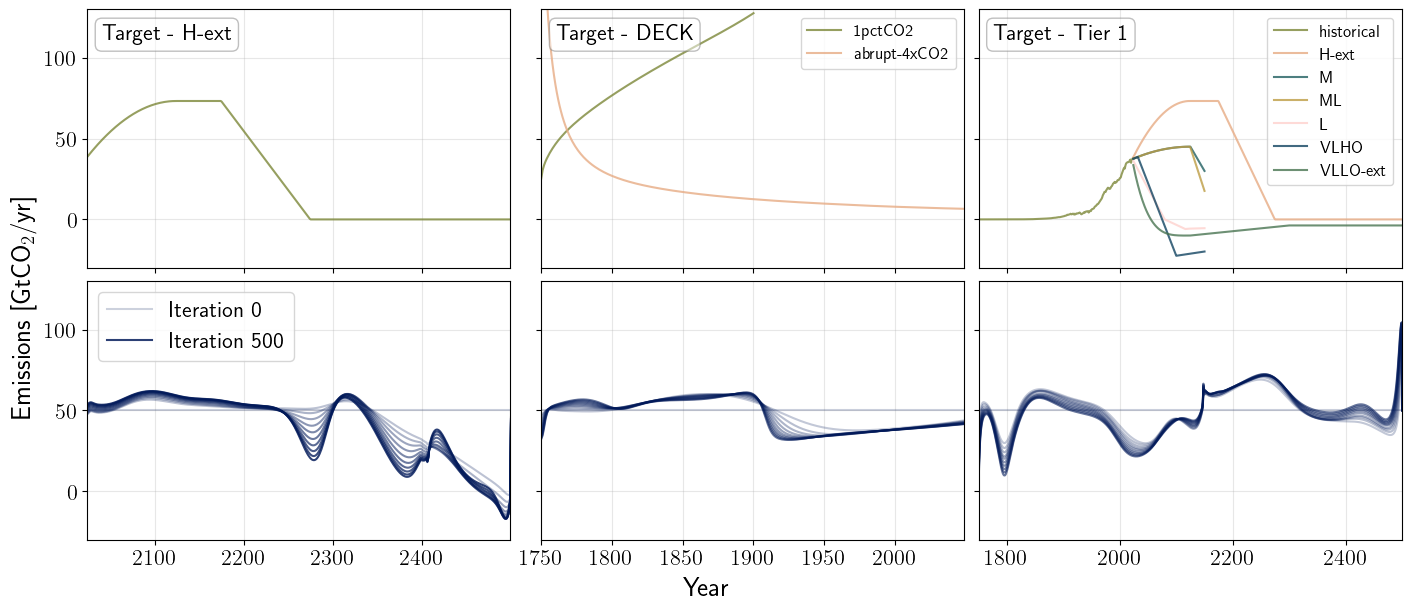

In [226]:
targets = ['H-ext','DECK','Tier 1']
utils_plotting.plot_emissions_grid(opt_emissions, target_emissions, years, targets, groups, save=True)

### Figure X: Fourier transform of all ghgs solution

In [159]:
path = 'checkpoints/multi/inverse_constant_tier1_all_ghgs.pkl'
agents = ['CO2','CH4','N2O','Sulfur','BC']

opt_emissions = []
with open(path, "rb") as f:
  raw = pickle.load(f)
out = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }
for a in agents:
  opt_emissions.append(out['U_traj'][-1][a])

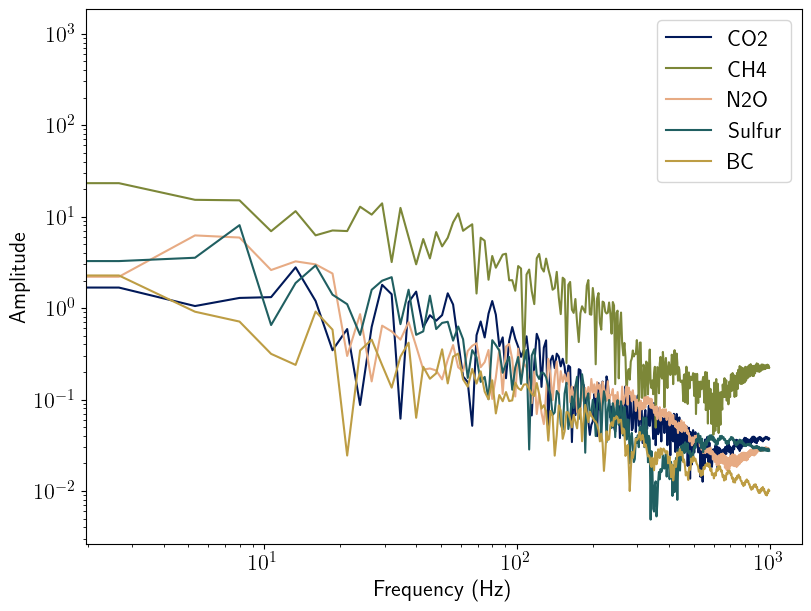

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm

# 1. Generate Sample Data (3 different signals)
# Sampling parameters
fs = 2000.0       # Sampling rate (Hz)
T = 1.0 / fs      # Sampling interval

# 2. Setup the Plot
# Create subplots based on the number of arrays
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True, sharex=True)

for i, emis in enumerate(opt_emissions):
    N = len(emis)
    yf = np.fft.fft(emis)
    xf = np.fft.fftfreq(N, T)

    # Plot on the SAME axis 'ax'
    ax.loglog(xf[:N//2], 2.0/N * np.abs(yf[:N//2]), c=cm.batlowWS(i + 1), label=f'{agents[i]}')
#ax.set_xlim([0,1000])
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Amplitude')
ax.legend()
# High power at high frequencies, low/constant power at low frequencies

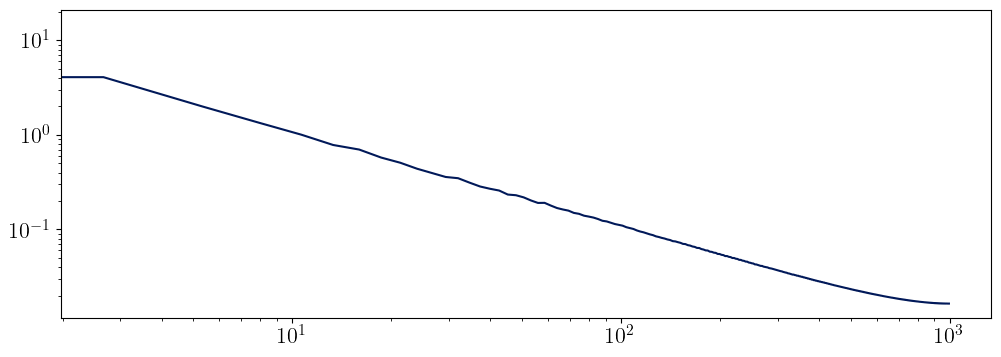

In [197]:
# Fourier transform of individual tier 1 scenarios and sum over all scenarios??
# Transform over heaviside?
# Transform over resulting temperature?
temp = out['train_temp_traj'][-1][0]
N = len(temp)
yf = np.fft.fft(temp)
xf = np.fft.fftfreq(N, T)

# Plot on the SAME axis 'ax'
fig, ax = plt.subplots()
ax.loglog(xf[:N//2], 2.0/N * np.abs(yf[:N//2]), c=cm.batlowWS(1))

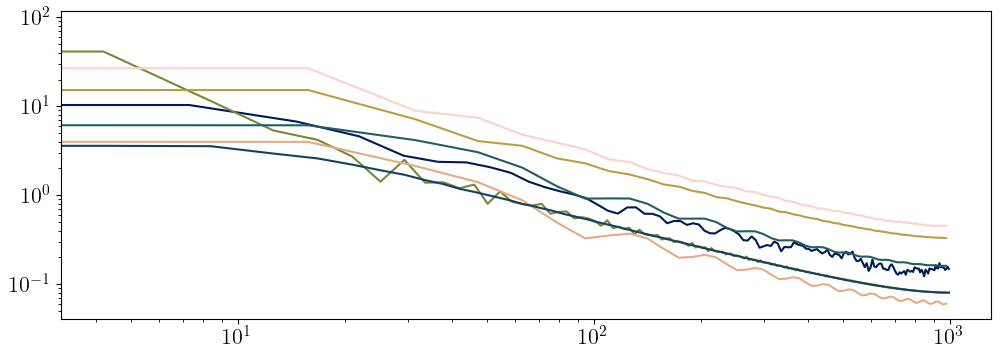

In [198]:
fig, ax = plt.subplots()
for i, emis in enumerate(target_emissions[-1]):
    N = len(emis)
    yf = np.fft.fft(emis)
    xf = np.fft.fftfreq(N, T)

    # Plot on the SAME axis 'ax'
    ax.loglog(xf[:N//2], 2.0/N * np.abs(yf[:N//2]), c=cm.batlowWS(i + 1))

In [200]:
agents = ['CO2']
#emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = generate_calib_data(agents)

path = 'checkpoints/co2/inverse_constant_tier1_co2_only.pkl'

opt_emissions = []
with open(path, "rb") as f:
  raw = pickle.load(f)
out = {
      "U_traj": [_tree_to_jnp(u) for u in raw["U_traj"]],
      "errors": jnp.asarray(raw["errors"], dtype=jnp.float32),
      "opt_state": _tree_to_jnp(raw["opt_state"]),
      "step_count": int(raw["step_count"]),
      "time_weights": None if raw["time_weights"] is None else _tree_to_jnp(raw["time_weights"]),
      "meta": raw.get("meta", {}),
      "preds_traj": raw["preds_traj"],
      "train_temp_traj": raw["train_temp_traj"],
  }
for series in out['U_traj']:
  opt_emissions.append(series['CO2'])

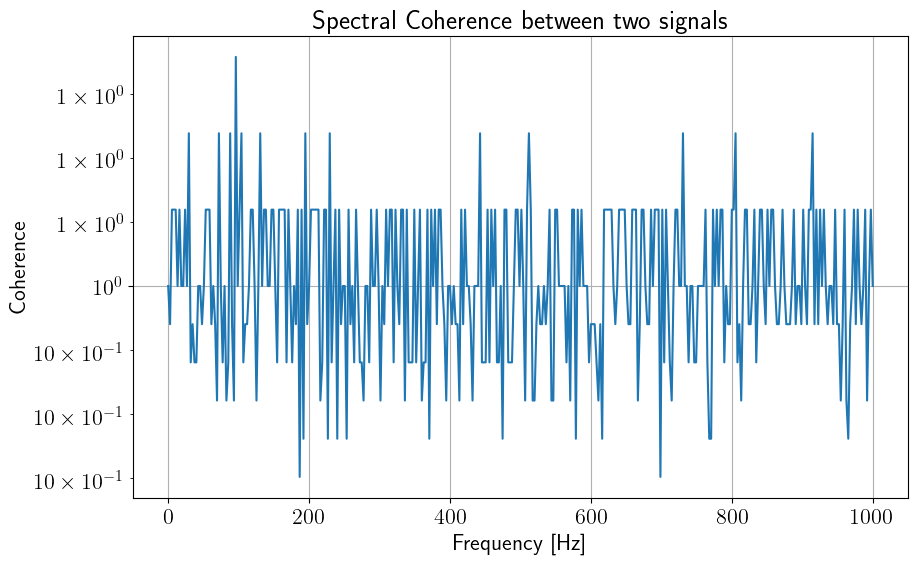

In [207]:
from scipy import signal
f, Cxy = signal.coherence(opt_emissions[-1], out['train_temp_traj'][-1][0], fs, nperseg=750)

# Plot the coherence
plt.figure(figsize=(10, 6))
plt.semilogy(f, Cxy) # Use semilogy for better visualization of coherence values
plt.xlabel('Frequency [Hz]')
plt.ylabel('Coherence')
plt.title('Spectral Coherence between two signals')
plt.grid(True)
plt.show()